In [1]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct

In [2]:
# ========================
# Define System Parameters
# ========================
f_ref = 10e6       # Reference frequency (10 MHz)
f_out = 2.44e9     # Center output frequency (2.44 GHz)
N = f_out / f_ref  # Divide ratio (244)

K_vco_hz = 120.42e6    # VCO Gain in Hz/V
I_cp = 50e-6       # Charge pump current (50 uA)

f_c = 200e3        # Target loop bandwidth (200 kHz)
phi_m_deg = 60     # Target phase margin (60 degrees)

In [3]:
# ================================
# Calculate Loop Filter Components
# ================================
w_c = 2 * np.pi * f_c
phi_m_rad = phi_m_deg * (np.pi / 180)

# Gamma (b) is the ratio of the pole to zero frequency to maximize phase margin
b = (1 + np.sin(phi_m_rad)) / (1 - np.sin(phi_m_rad))

# Time constants
tau_z = np.sqrt(b) / w_c
tau_p = 1 / (w_c * np.sqrt(b))

# Total capacitance needed
C_tot = (I_cp * K_vco_hz * np.sqrt(b)) / (N * w_c**2)
k = 1

# Component values with scaling factor k
C2 = C_tot * (1 / (b * (1 + k)))
C1 = C_tot - C2
R1 = tau_z / C1
R2 = k * R1

print(f"--- Filter Components ---")
print(f"C1 = {C1 * 1e12:.4f} pF")
print(f"C2 = {C2 * 1e12:.4f} pF")
print(f"R1 = {R1 / 1e3:.4f} kOhm")
print(f"R2 = {R2 / 1e3:.4f} kOhm")

--- Filter Components ---
C1 = 56.2250 pF
C2 = 2.0935 pF
R1 = 52.8212 kOhm
R2 = 52.8212 kOhm


In [4]:
# ========================
# Build Transfer Functions
# ========================
s = ct.TransferFunction.s

# Phase Detector / Charge Pump Gain
K_pd = I_cp / (2 * np.pi)

# VCO Gain (rad/s/V)
K_vco_rad = 2 * np.pi * K_vco_hz

# Loop Filter Impedance F(s)
# F(s) = (s*R1*C1 + 1) / (s^2*C1*C2*(R1+R2) + s*(C1+C2))
num_F = [R1 * C1, 1]
den_F = [C1 * C2 * (R1 + R2), (C1 + C2), 0]
F_lf = ct.TransferFunction(num_F, den_F)

# Open-Loop Transfer Function: G_open(s) = (K_pd * K_vco_rad * F_lf) / (N * s)
G_open = (K_pd * K_vco_rad * F_lf) / (N * s)

# Closed-Loop Transfer Function: H(s) = (N * G_open) / (1 + G_open)
H_closed = (N * G_open) / (1 + G_open)

c:\Users\acham\.conda\envs\fpll\Lib\site-packages\control\freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


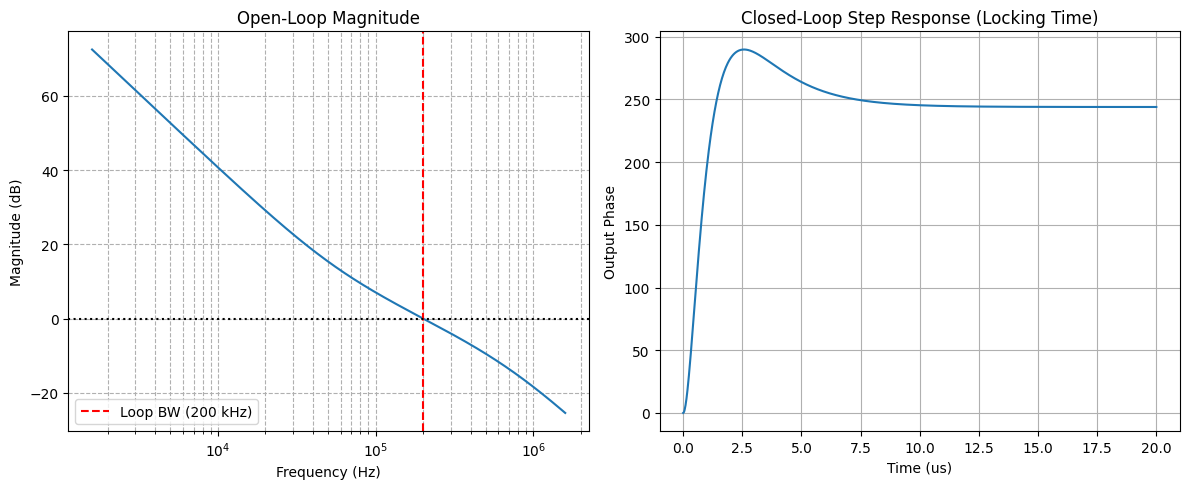

--- Verification ---
Achieved Phase Margin: 60.00 degrees at 200.00 kHz


In [5]:
# ================
# Analyze and Plot
# ================
plt.figure(figsize=(12, 5))

# Bode Plot (Open Loop)
plt.subplot(1, 2, 1)
mag, phase, omega = ct.bode(G_open, omega_limits=(1e4, 1e7), plot=False)
plt.semilogx(omega / (2 * np.pi), 20 * np.log10(mag))
plt.axvline(f_c, color='r', linestyle='--', label=f'Loop BW ({f_c/1e3:.0f} kHz)')
plt.axhline(0, color='k', linestyle=':')
plt.title("Open-Loop Magnitude")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.legend()
plt.grid(True, which="both", ls="--")

# Step Response (Closed Loop)
plt.subplot(1, 2, 2)
time, response = ct.step_response(H_closed, T=np.linspace(0, 20e-6, 1000))
plt.plot(time * 1e6, response)
plt.title("Closed-Loop Step Response (Locking Time)")
plt.xlabel("Time (us)")
plt.ylabel("Output Phase")
plt.grid(True)

plt.tight_layout()
plt.show()

# Verify Stability Margins
gm, pm, wg, wp = ct.margin(G_open)
print(f"--- Verification ---")
print(f"Achieved Phase Margin: {pm:.2f} degrees at {wp / (2 * np.pi) / 1e3:.2f} kHz")